# Introducción a Señales Biomédicas
# Activación muscular según tipo de carga mediante sEMG y videogrametría en transporte público en universitarios

# 1. Objetivo general

Evaluar la activación muscular y la asimetría bilateral del trapecio superior y del erector espinal durante diferentes condiciones de carga, comparando estudiantes que utilizan transporte público con estudiantes que utilizan automóvil particular.

---

# 2. Participantes

### Grupo 1
Usuarios frecuentes de transporte público.

### Grupo 2

Usuarios frecuentes de automóvil particular.

---

# 3. Músculos analizados

- Trapecio superior derecho
- Trapecio superior izquierdo
- Erector espinal derecho
- Erector espinal izquierdo

---

# 4. Condiciones experimentales

| Condición | Descripción |
|------------|----------------------------|
| Basal | Posición anatómica sin carga |
| Mochila 1 asa (ligera) | Mochila ligera cargada con una sola asa |
| Mochila 2 asas (ligera) | Mochila ligera cargada normalmente |
| Mochila 1 asa (pesada) | Mochila pesada cargada con una sola asa |
| Mochila 2 asas (pesada) | Mochila pesada cargada normalmente |

---

**Frecuencia de muestreo: Fs = 1000 Hz**
# 5. Procesamiento de la señal EMG

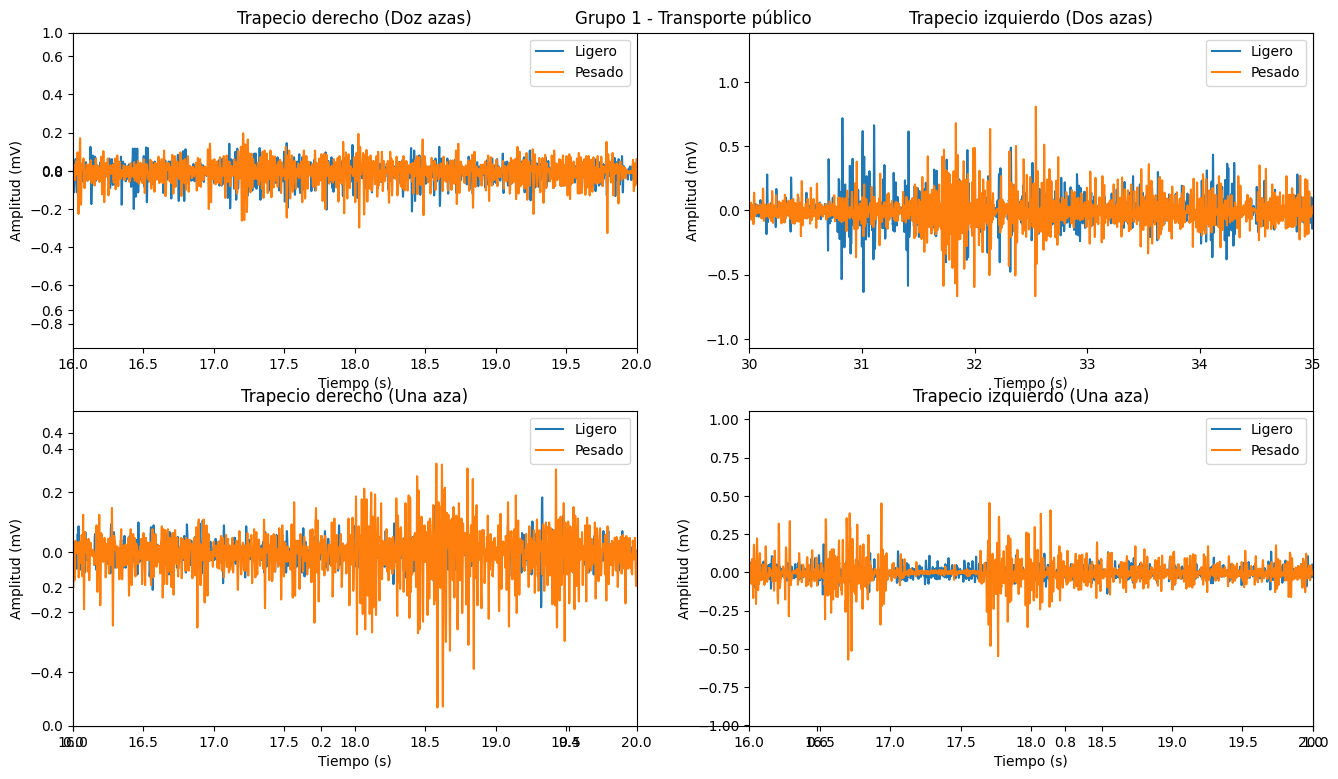

In [72]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# Cargar señales
def cargar_datos(carpeta):

    senales = {}

    carpeta = Path(carpeta)

    for archivo in carpeta.glob("*.txt"):

        datos = pd.read_csv(
            archivo,
            sep="\t",
            comment="#",
            header=None
        )

        datos = datos.dropna(axis=1, how="all")
        datos.columns = ["nSeq", "I1", "I2", "O1", "O2", "EMG"]
        datos = datos["EMG"]
        senales[archivo.stem] = datos

    return senales

def adc_a_mV(adc, VCC=3.3, G=1000):
    return ((adc / 1024) - 0.5) * VCC / G * 1000
fs = 1000

t_publico = cargar_datos("transporte_publico")
t_privado = cargar_datos("transporte_privado")

# Plot
trapecio_der_2_lig = adc_a_mV(t_publico["Trapecio_der_dos_azas_pligero"])
trapecio_der_2_pes = adc_a_mV(t_publico["Trapecio_der_dos_azas_ppesado"])
trapecio_der_1_lig = adc_a_mV(t_publico["Trapecio_der_una_aza_pligero"])
trapecio_der_1_pes = adc_a_mV(t_publico["Trapecio_der_una_aza_ppesado"])

trapecio_izq_2_lig = adc_a_mV(t_publico["Trapecio_izq_dos_azas_pligero"])
trapecio_izq_2_pes = adc_a_mV(t_publico["Trapecio_izq_dos_azas_ppesado"])
trapecio_izq_1_lig = adc_a_mV(t_publico["Trapecio_izq_una_aza_pligero"])
trapecio_izq_1_pes = adc_a_mV(t_publico["Trapecio_izq_una_aza_ppesado"])


t_trap_der_2_lig = np.arange(len(trapecio_der_2_lig)) / fs
t_trap_der_2_pes = np.arange(len(trapecio_der_2_pes)) / fs
t_trap_der_1_lig = np.arange(len(trapecio_der_1_lig)) / fs
t_trap_der_1_pes = np.arange(len(trapecio_der_1_pes)) / fs

t_trap_izq_2_lig = np.arange(len(trapecio_izq_2_lig)) / fs
t_trap_izq_2_pes = np.arange(len(trapecio_izq_2_pes)) / fs
t_trap_izq_1_lig = np.arange(len(trapecio_izq_1_lig)) / fs
t_trap_izq_1_pes = np.arange(len(trapecio_izq_1_pes)) / fs

plt.figure(figsize=(16,9))
plt.title("Grupo 1 - Transporte público")

plt.subplot(2,2,1)
plt.plot(t_trap_der_2_lig,trapecio_der_2_lig, label="Ligero")
plt.plot(t_trap_der_2_pes,trapecio_der_2_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio derecho (Doz azas)")
plt.legend()
plt.xlim(16,20)


plt.subplot(2,2,2)
plt.plot(t_trap_izq_2_lig,trapecio_izq_2_lig, label="Ligero")
plt.plot(t_trap_izq_2_pes,trapecio_izq_2_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio izquierdo (Dos azas)")
plt.legend()
plt.xlim(30,35)

plt.subplot(2,2,3)
plt.plot(t_trap_der_1_lig,trapecio_der_1_lig, label="Ligero")
plt.plot(t_trap_der_1_pes,trapecio_der_1_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio derecho (Una aza)")
plt.legend()
plt.xlim(16,20)

plt.subplot(2,2,4)
plt.plot(t_trap_izq_1_lig,trapecio_izq_1_lig, label="Ligero")
plt.plot(t_trap_izq_1_pes,trapecio_izq_1_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio izquierdo (Una aza)")
plt.legend()
plt.xlim(16,20)
plt.show()

Se puede observar que a mayor carga el usuario debe soportar en la mochila, mayor es la activación muscular en ambos trapecios. Se puede ver que las señales correspondientes a mochilas pesadas generaron señales más intensas con mayor amplitud que opacan a las correpsondientes a una mochila ligera.

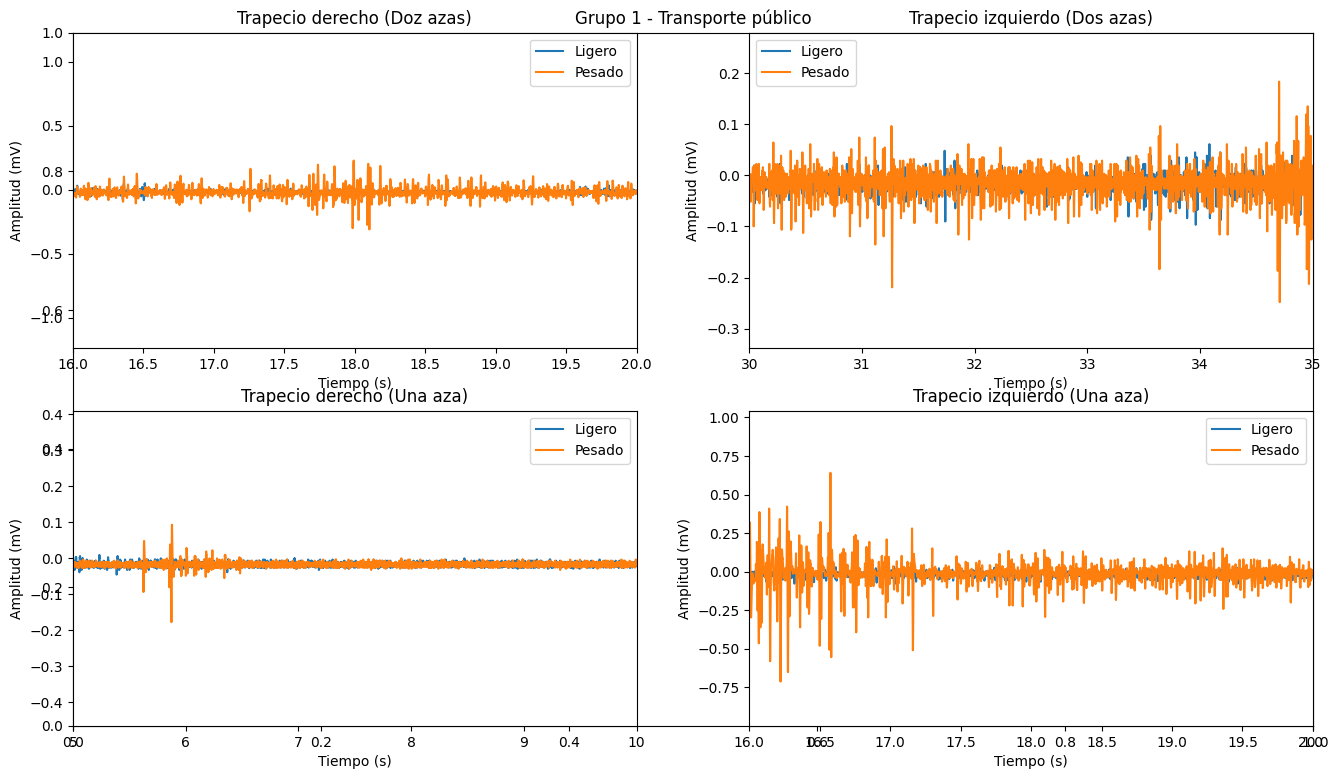

In [74]:
trapecio_der_2_lig = adc_a_mV(t_privado["Trapecio_der_dos_azas_pligero"])
trapecio_der_2_pes = adc_a_mV(t_privado["Trapecio_der_dos_azas_ppesado"])
trapecio_der_1_lig = adc_a_mV(t_privado["Trapecio_der_una_aza_pligero"])
trapecio_der_1_pes = adc_a_mV(t_privado["Trapecio_der_una_aza_ppesado"])

trapecio_izq_2_lig = adc_a_mV(t_privado["Trapecio_izq_dos_azas_pligero"])
trapecio_izq_2_pes = adc_a_mV(t_privado["Trapecio_izq_dos_azas_ppesado"])
trapecio_izq_1_lig = adc_a_mV(t_privado["Trapecio_izq_una_aza_pligero"])
trapecio_izq_1_pes = adc_a_mV(t_privado["Trapecio_izq_una_aza_ppesado"])


t_trap_der_2_lig = np.arange(len(trapecio_der_2_lig)) / fs
t_trap_der_2_pes = np.arange(len(trapecio_der_2_pes)) / fs
t_trap_der_1_lig = np.arange(len(trapecio_der_1_lig)) / fs
t_trap_der_1_pes = np.arange(len(trapecio_der_1_pes)) / fs

t_trap_izq_2_lig = np.arange(len(trapecio_izq_2_lig)) / fs
t_trap_izq_2_pes = np.arange(len(trapecio_izq_2_pes)) / fs
t_trap_izq_1_lig = np.arange(len(trapecio_izq_1_lig)) / fs
t_trap_izq_1_pes = np.arange(len(trapecio_izq_1_pes)) / fs

plt.figure(figsize=(16,9))
plt.title("Grupo 1 - Transporte público")

plt.subplot(2,2,1)
plt.plot(t_trap_der_2_lig,trapecio_der_2_lig, label="Ligero")
plt.plot(t_trap_der_2_pes,trapecio_der_2_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio derecho (Doz azas)")
plt.legend()
plt.xlim(16,20)


plt.subplot(2,2,2)
plt.plot(t_trap_izq_2_lig,trapecio_izq_2_lig, label="Ligero")
plt.plot(t_trap_izq_2_pes,trapecio_izq_2_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio izquierdo (Dos azas)")
plt.legend()
plt.xlim(30,35)

plt.subplot(2,2,3)
plt.plot(t_trap_der_1_lig,trapecio_der_1_lig, label="Ligero")
plt.plot(t_trap_der_1_pes,trapecio_der_1_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio derecho (Una aza)")
plt.legend()
plt.xlim(5,10)

plt.subplot(2,2,4)
plt.plot(t_trap_izq_1_lig,trapecio_izq_1_lig, label="Ligero")
plt.plot(t_trap_izq_1_pes,trapecio_izq_1_pes, label="Pesado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Trapecio izquierdo (Una aza)")
plt.legend()
plt.xlim(16,20)
plt.show()

Para la persona que suele viajar en transporte privado, el comportamiento es el esperado. La activación muscular es mayor si se carga una mochila de mayor peso para ambos trapecios. Se puede ver que la señal del peso mayor opaca a la señal débil del peso ligero.